# import and config

In [24]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer
import transformers

In [25]:
import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()

True

In [26]:
transformers.logging.set_verbosity_error()

# Get dataset

In [27]:
splits = {'train': 'vianli_train.jsonl', 'validation': 'vianli_dev.jsonl', 'test': 'vianli_test.jsonl'}
df_train = pd.read_json("hf://datasets/uitnlp/ViANLI/" + splits["train"], lines=True)
df_valid = pd.read_json("hf://datasets/uitnlp/ViANLI/" + splits["validation"], lines=True)
df_test = pd.read_json("hf://datasets/uitnlp/ViANLI/" + splits["test"], lines=True)
df_train[:5]

,uid,premise,hypothesis,label
0,uit_Adver_365_3_11_02,Tọa đàm do Tổng cục Du lịch phối hợp với báo đ...,"Đầu tháng 4 có một buổi gặp mặt trao đổi, nói ...",entailment
1,uit_Adver_1405_5_11_08,Bệnh viện Đa khoa tỉnh Bắc Ninh xin hội chẩn 2...,"Để giúp các chuyên gia đầu ngành, bệnh viện Đa...",entailment
2,uit_Adver_304_2_11_02,"Bộ trưởng Du lịch, tiến sĩ Abdulla Mausoom xác...","3V đại diện cho Visit (Tham quan), Vaccine (Ti...",entailment
3,uit_Adver_1124_1_11_06,Nhờ sự chuyển dịch của người dùng lên trực tuy...,Amazon có doanh thu 3 tháng đầu năm vượt trội ...,entailment
4,uit_Adver_819_3_11_05,Lượng neutron ngày tăng hé lộ FCM đang trải qu...,Hỗn hợp các chất phóng xạ đặc sệt gồm uranium ...,entailment


# Checking imbalance

In [28]:
np.sort(df_train["label"].unique())

array(['contradiction', 'entailment', 'neutral'], dtype=object)

In [29]:
count_label = np.zeros(len(np.sort(df_train["label"].unique())))
for i, x in enumerate(np.sort(df_train["label"].unique())) :
    count_label[i] = df_train["label"].value_counts()[x]
count_label, len(count_label)


(array([2473., 2615., 2924.]), 3)

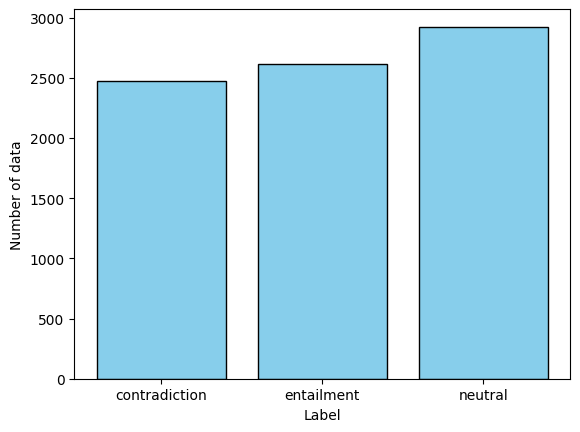

In [31]:
plt.bar(np.sort(df_train["label"].unique()), count_label, color="skyblue", edgecolor='black')
plt.xlabel("Label")
plt.ylabel("Number of data")
plt.show()

# Tokenize

In [ ]:
phobert = AutoModel.from_pretrained("vinai/phobert-base")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:
tokenizer.vocab_size

64000

In [ ]:
example = "Tôi yêu Liên Minh Huyền Thoại"
output_example = tokenizer(example)
output_example

{'input_ids': [0, 218, 413, 3490, 1612, 4428, 17078, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}

In [ ]:
premise_example = "Tôi yêu Liên Minh Huyền Thoại"
hypothesis_example = "Tôi thất nghiệp"

output_example = tokenizer(premise_example, hypothesis_example)

tokenizer.decode(output_example['input_ids'])

'<s> Tôi yêu Liên Minh Huyền Thoại </s> </s> Tôi thất nghiệp </s>'

# Pick max length

In [ ]:
def count_token(row):
    ids = tokenizer(row['premise'], row['hypothesis'])['input_ids']
    return len(ids)

In [ ]:
df_train['token_length'] = df_train.apply(count_token, axis=1)
df_train[:5]

,uid,premise,hypothesis,label,token_length
0,uit_Adver_365_3_11_02,Tọa đàm do Tổng cục Du lịch phối hợp với báo đ...,"Đầu tháng 4 có một buổi gặp mặt trao đổi, nói ...",entailment,58
1,uit_Adver_1405_5_11_08,Bệnh viện Đa khoa tỉnh Bắc Ninh xin hội chẩn 2...,"Để giúp các chuyên gia đầu ngành, bệnh viện Đa...",entailment,80
2,uit_Adver_304_2_11_02,"Bộ trưởng Du lịch, tiến sĩ Abdulla Mausoom xác...","3V đại diện cho Visit (Tham quan), Vaccine (Ti...",entailment,87
3,uit_Adver_1124_1_11_06,Nhờ sự chuyển dịch của người dùng lên trực tuy...,Amazon có doanh thu 3 tháng đầu năm vượt trội ...,entailment,53
4,uit_Adver_819_3_11_05,Lượng neutron ngày tăng hé lộ FCM đang trải qu...,Hỗn hợp các chất phóng xạ đặc sệt gồm uranium ...,entailment,65


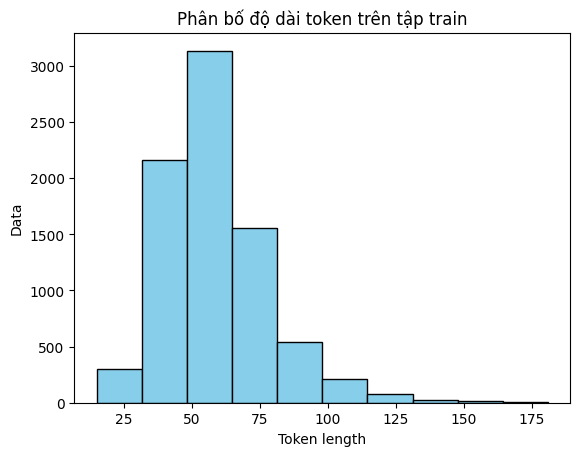

In [ ]:
plt.hist(df_train.token_length, color='skyblue', edgecolor='black')
plt.title('Phân bố độ dài token trên tập train')
plt.ylabel('Data')
plt.xlabel('Token length')
plt.show()

# Test dataset

In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.dataset import NLIDataset

In [ ]:
splits = {'train': 'vianli_train.jsonl', 'validation': 'vianli_dev.jsonl', 'test': 'vianli_test.jsonl'}
df = pd.read_json("hf://datasets/uitnlp/ViANLI/" + splits["train"], lines=True)

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
dataset = NLIDataset(df, tokenizer, max_length=128)

print("Từ điển nhãn của dataset ", dataset.label_dict)
print("Tổng số nhãn trong dataset ", len(dataset.label_dict))

sample = dataset[0]
print("Shape của input_ids ", sample["input_ids"].shape)
print("Nhãn của câu: ", sample["labels"])
print("Dịch ngược câu :", tokenizer.decode(sample["input_ids"]))



Từ điển nhãn của dataset  {'entailment': 0, 'neutral': 1, 'contradiction': 2}
Tổng số nhãn trong dataset  3
Shape của input_ids  torch.Size([128])
Nhãn của câu:  tensor(0)
Dịch ngược câu : <s> Tọa đàm do Tổng cục Du lịch phối hợp với báo điện tử VnExpress tổ chức ngày 3/4 tại FLC Sầm Sơn, Thanh Hóa. </s> </s> Đầu tháng 4 có một buổi gặp mặt trao đổi, nói chuyện thân mật của Tổng cục Du lịch. </s> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>
